In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Load the dataset
df_timezones = pd.read_excel('../data_fifa.xlsx', sheet_name='country_TZ')
df_weights = pd.read_csv('betting_team_probabilities_with_interest.csv')

In [2]:
name_replacements = {
    "South Korea": "Korea Republic",
    "Turkey": "Türkiye",
    "Czech Republic": "Czechia",
    "Bosnia & Herzegovina": "Bosnia and Herzegovina",
}
df_weights[["country", "opponent"]] = df_weights[["country", "opponent"]].replace(name_replacements)

In [4]:
from pathlib import Path

solution_dfs = {
    path.stem.removeprefix("solution_"): pd.read_csv(path)
    for path in sorted(Path("../results").glob("solution_*.csv"))
}

solution_dfs.keys()

dict_keys(['1-2-5-3-4', '2-4-3-1-5', '4-3-5-2-1', '5-1-2-3-4', '5-4-3-2-1'])

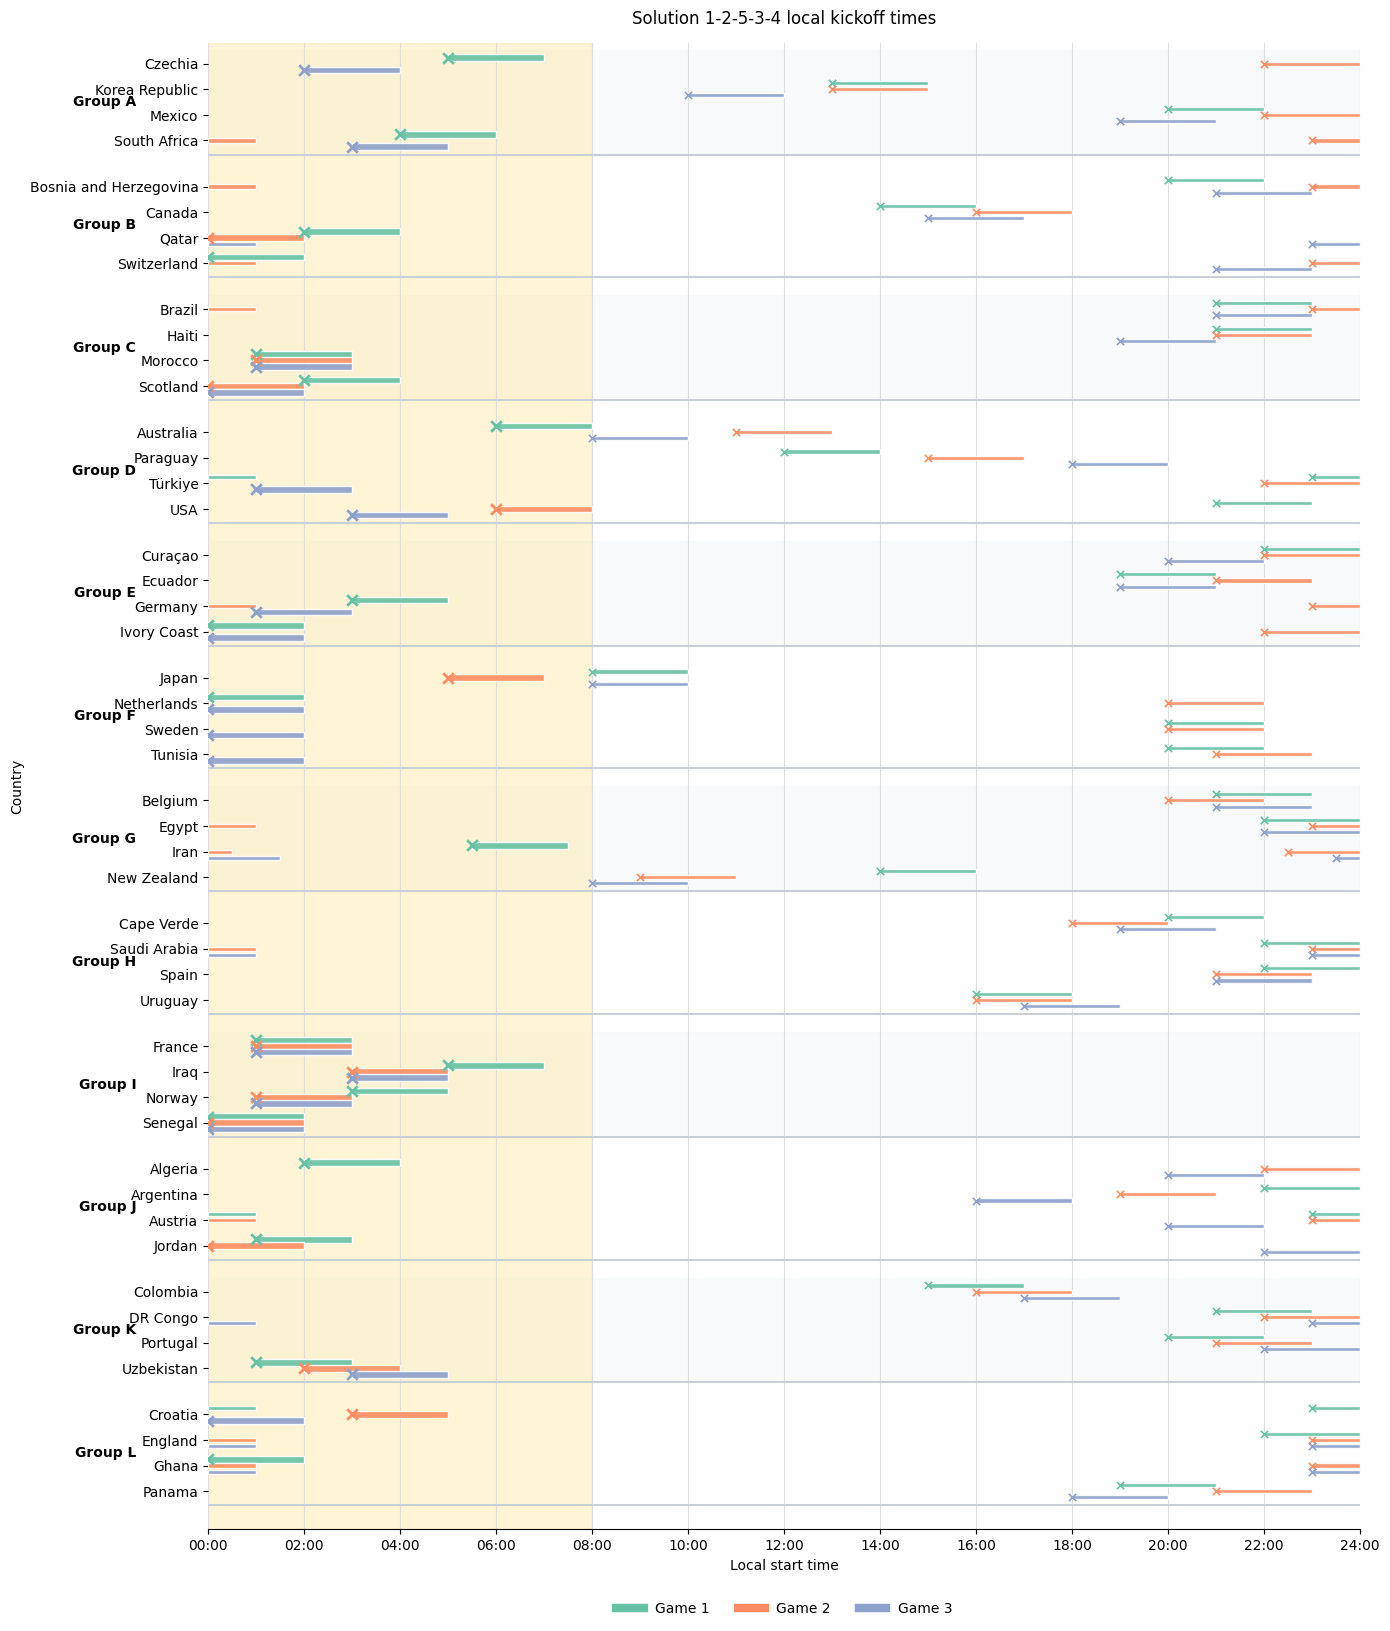

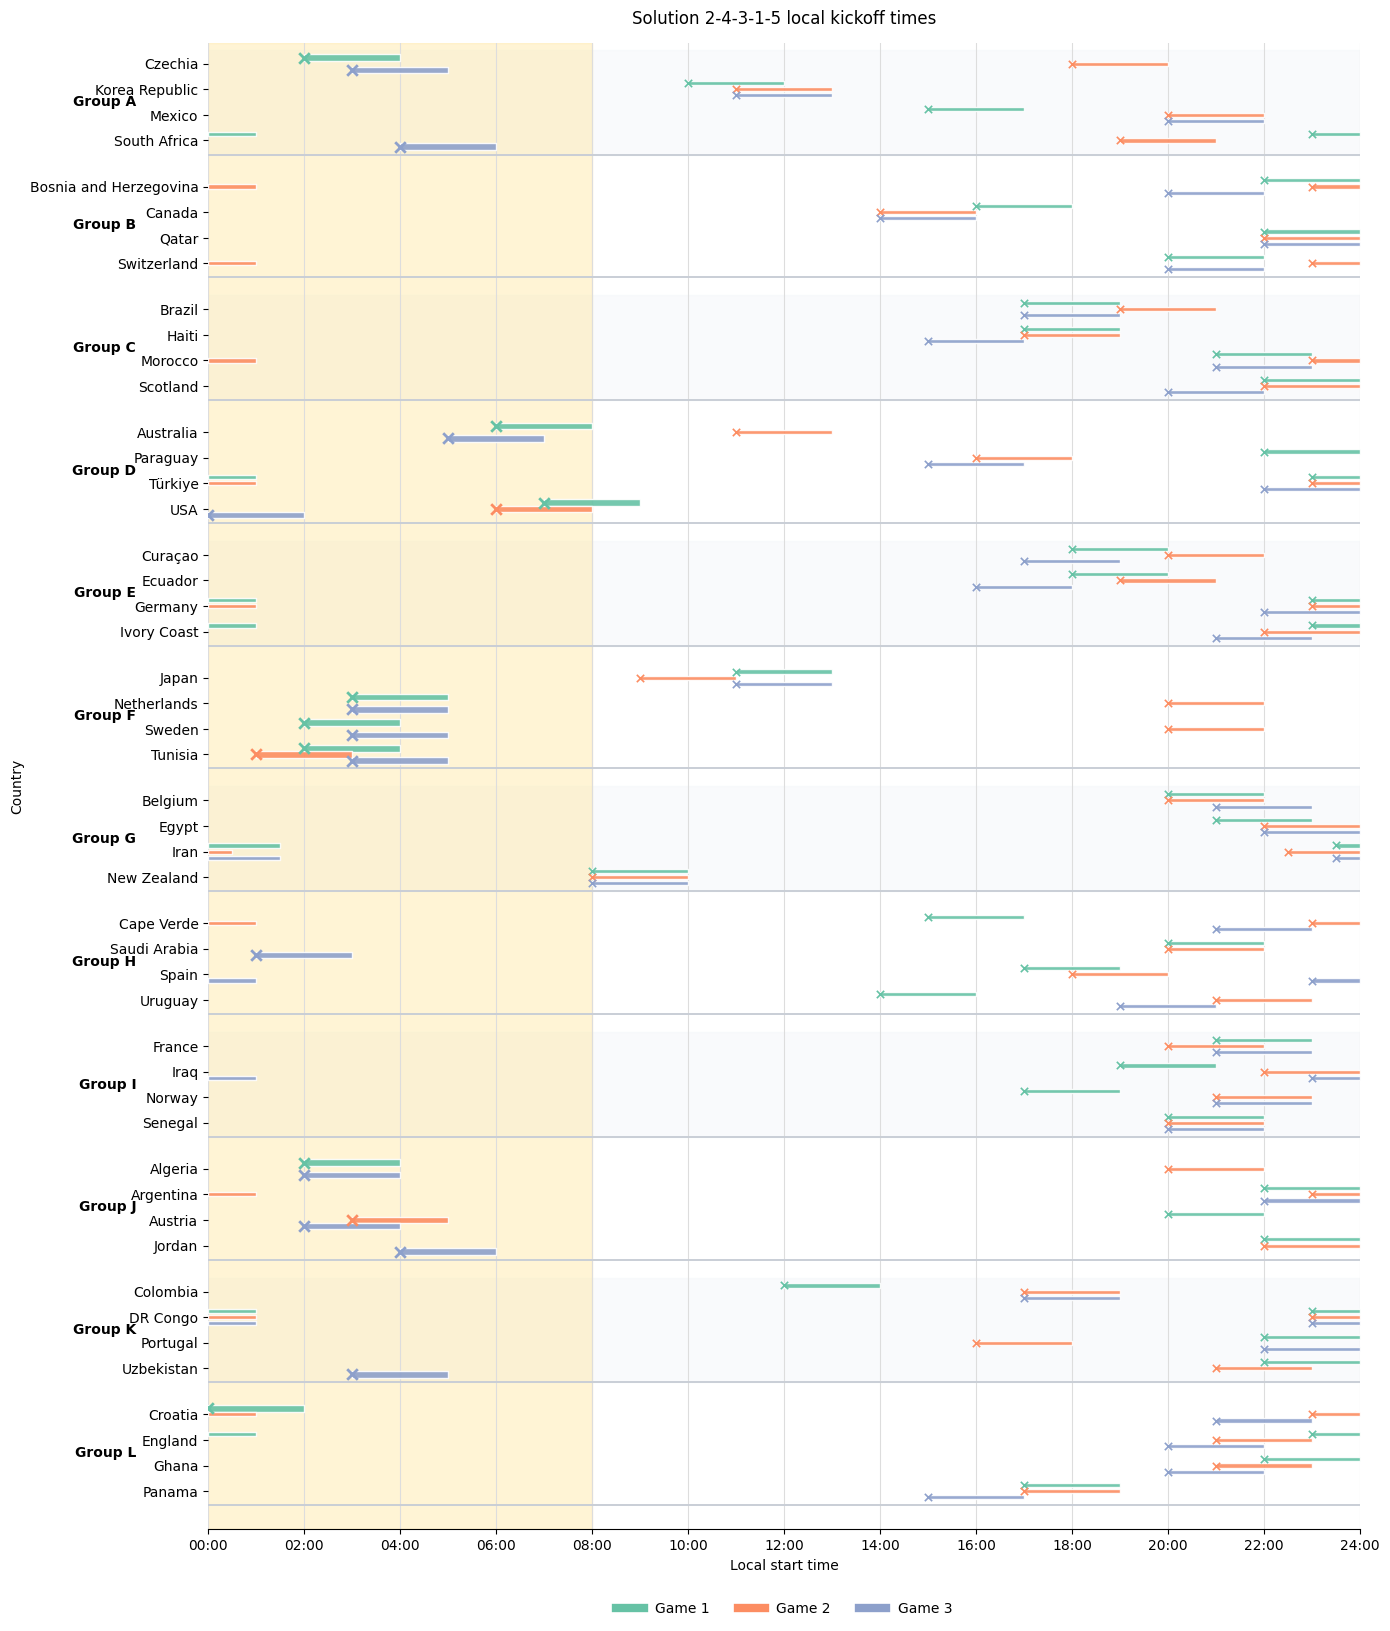

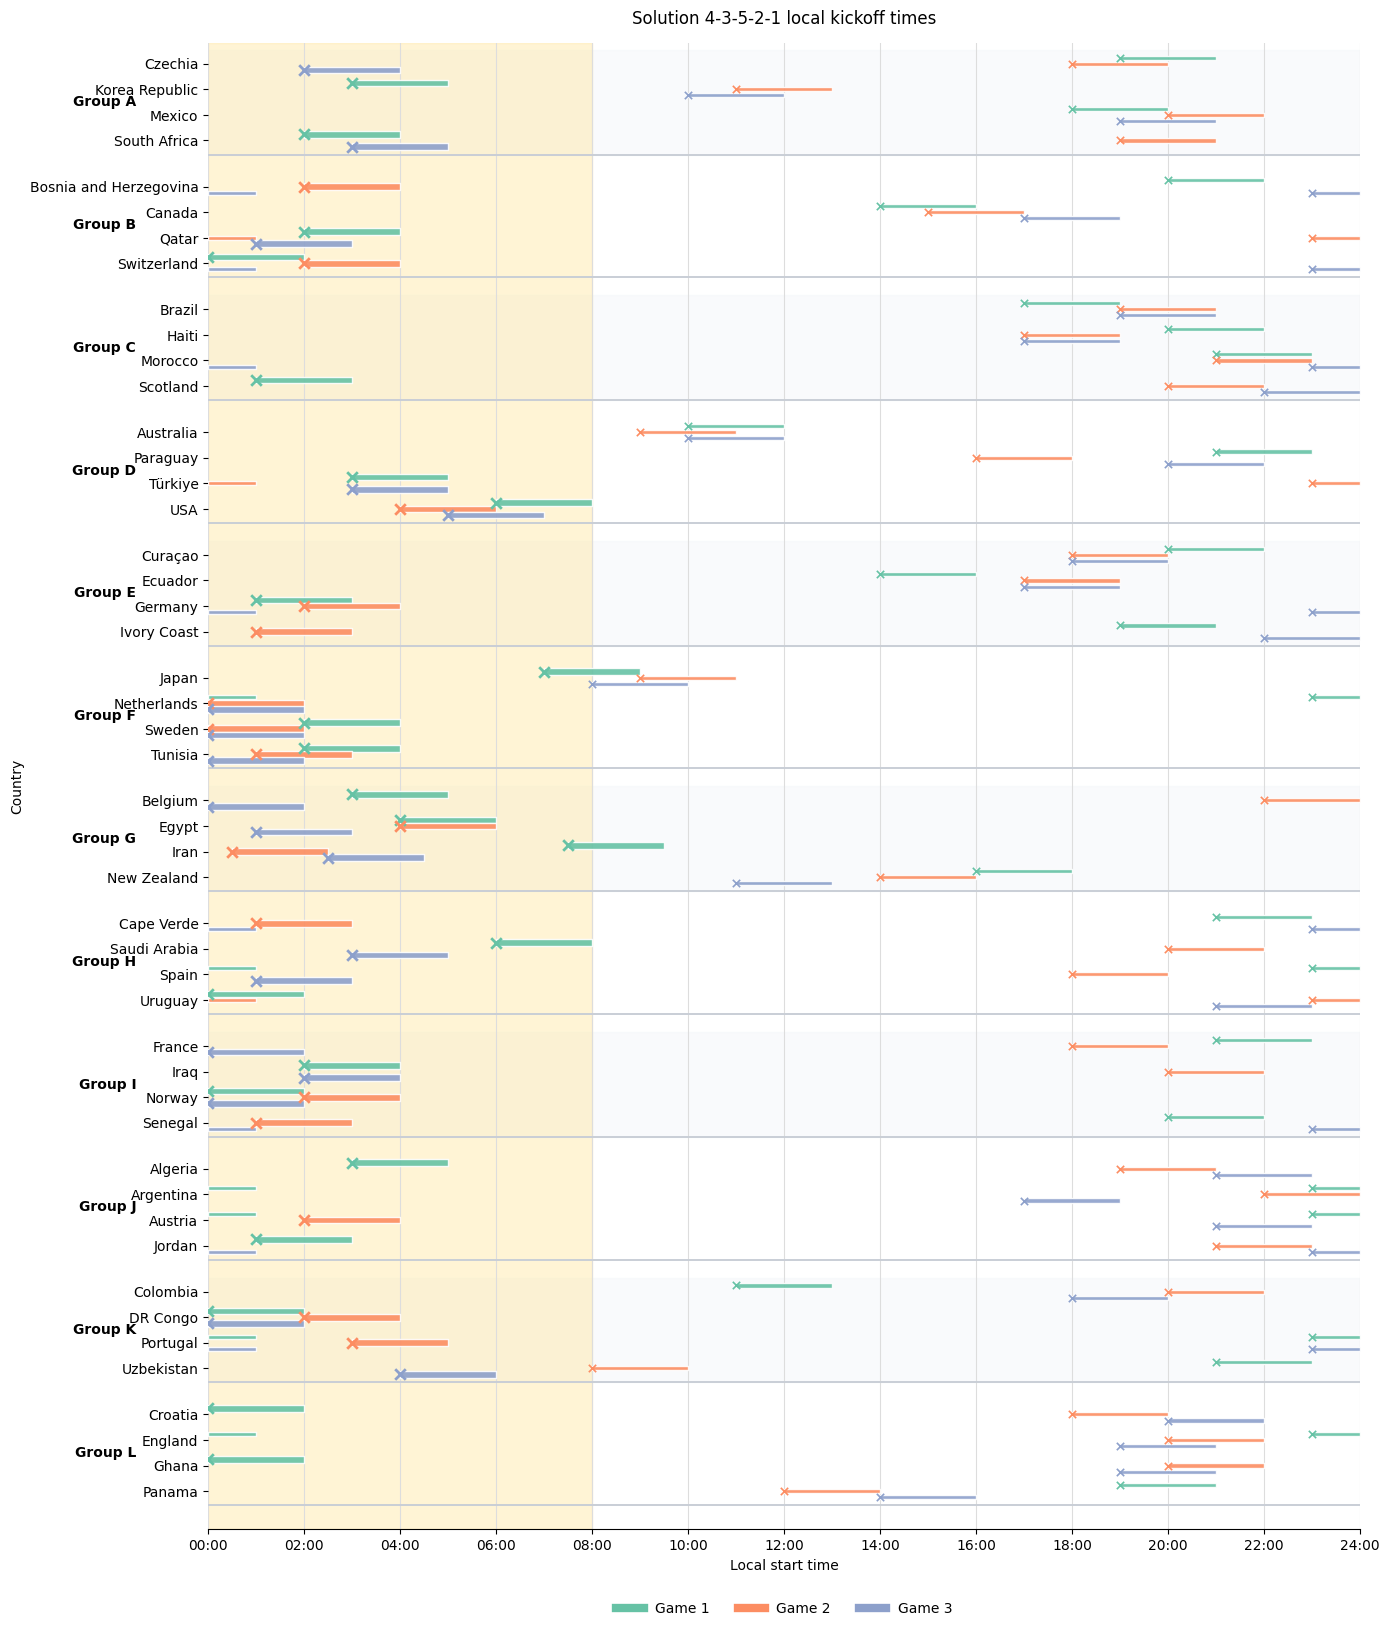

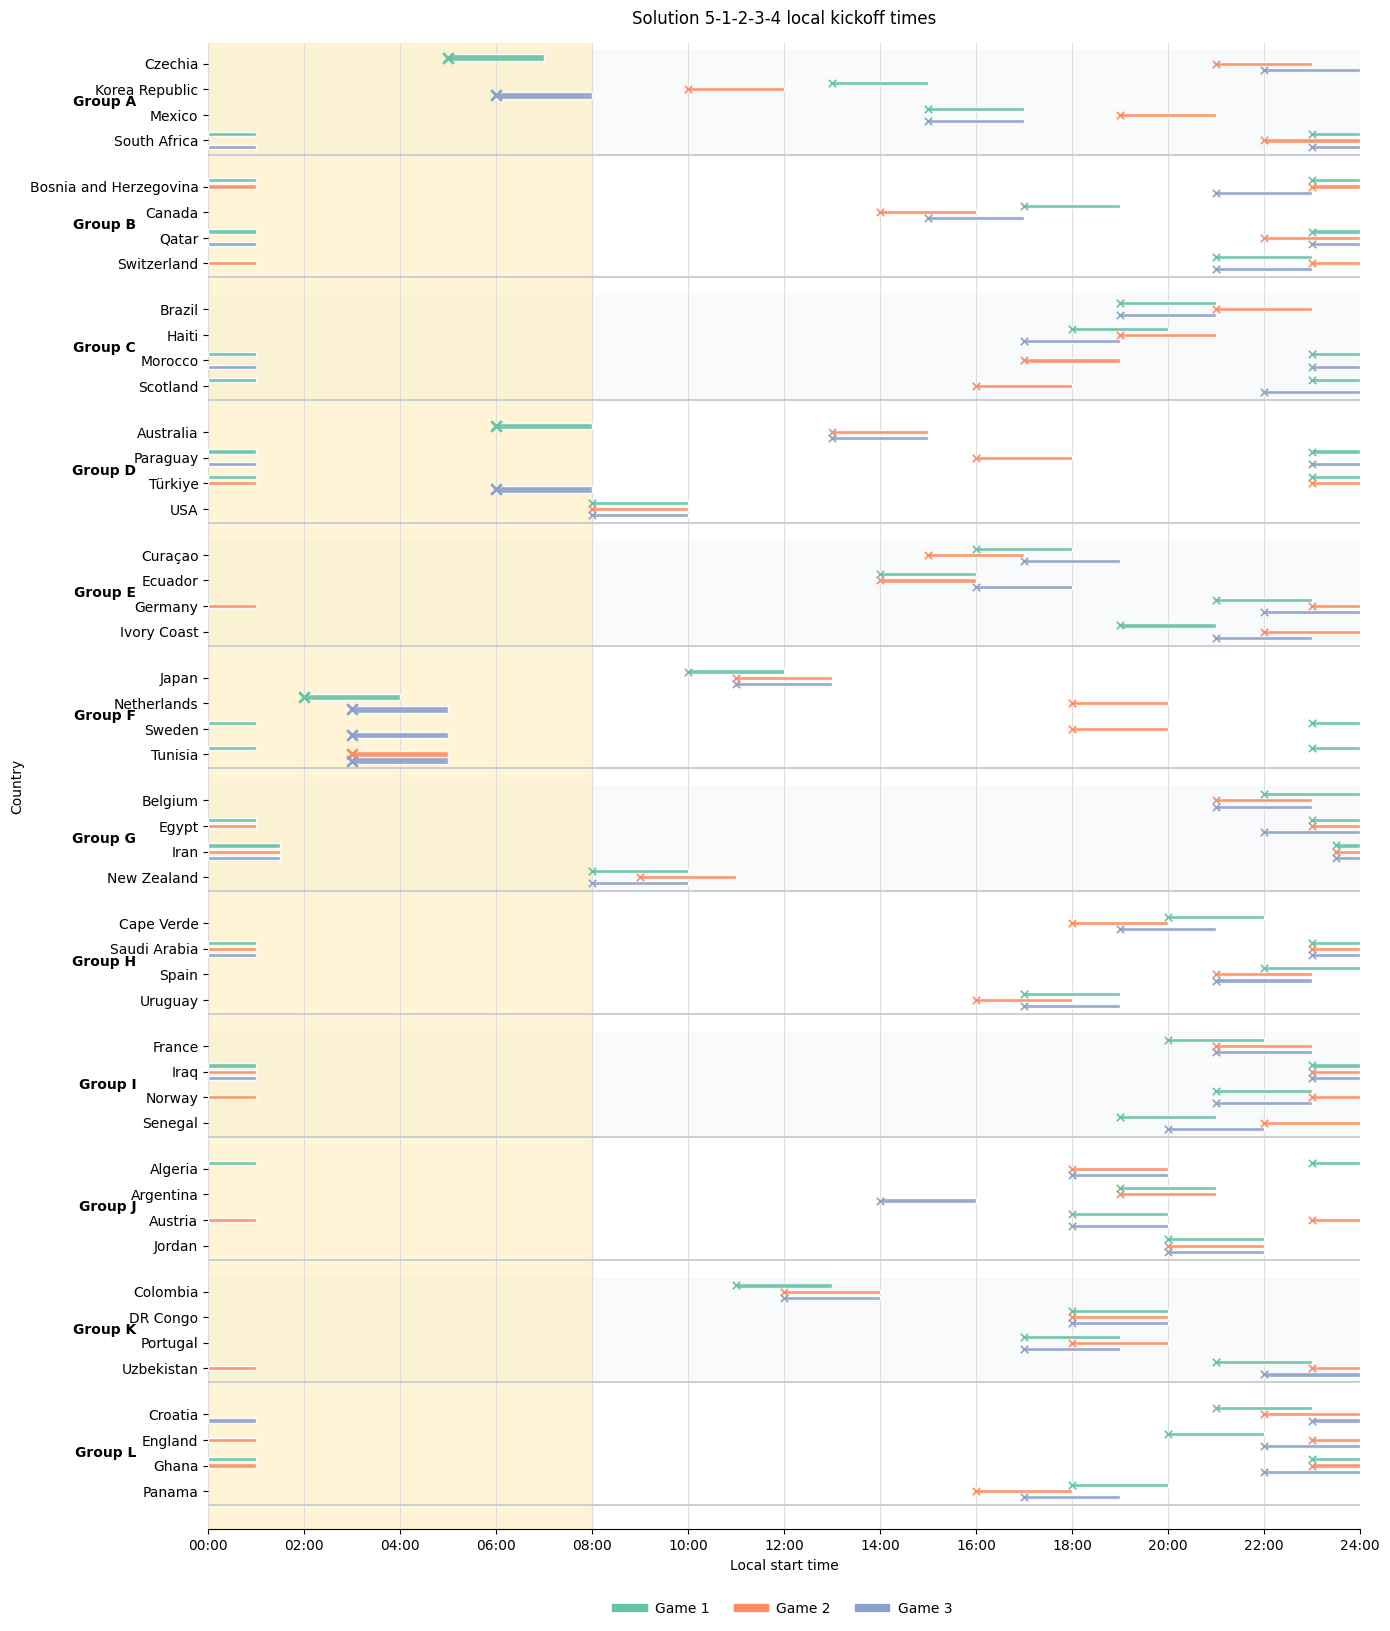

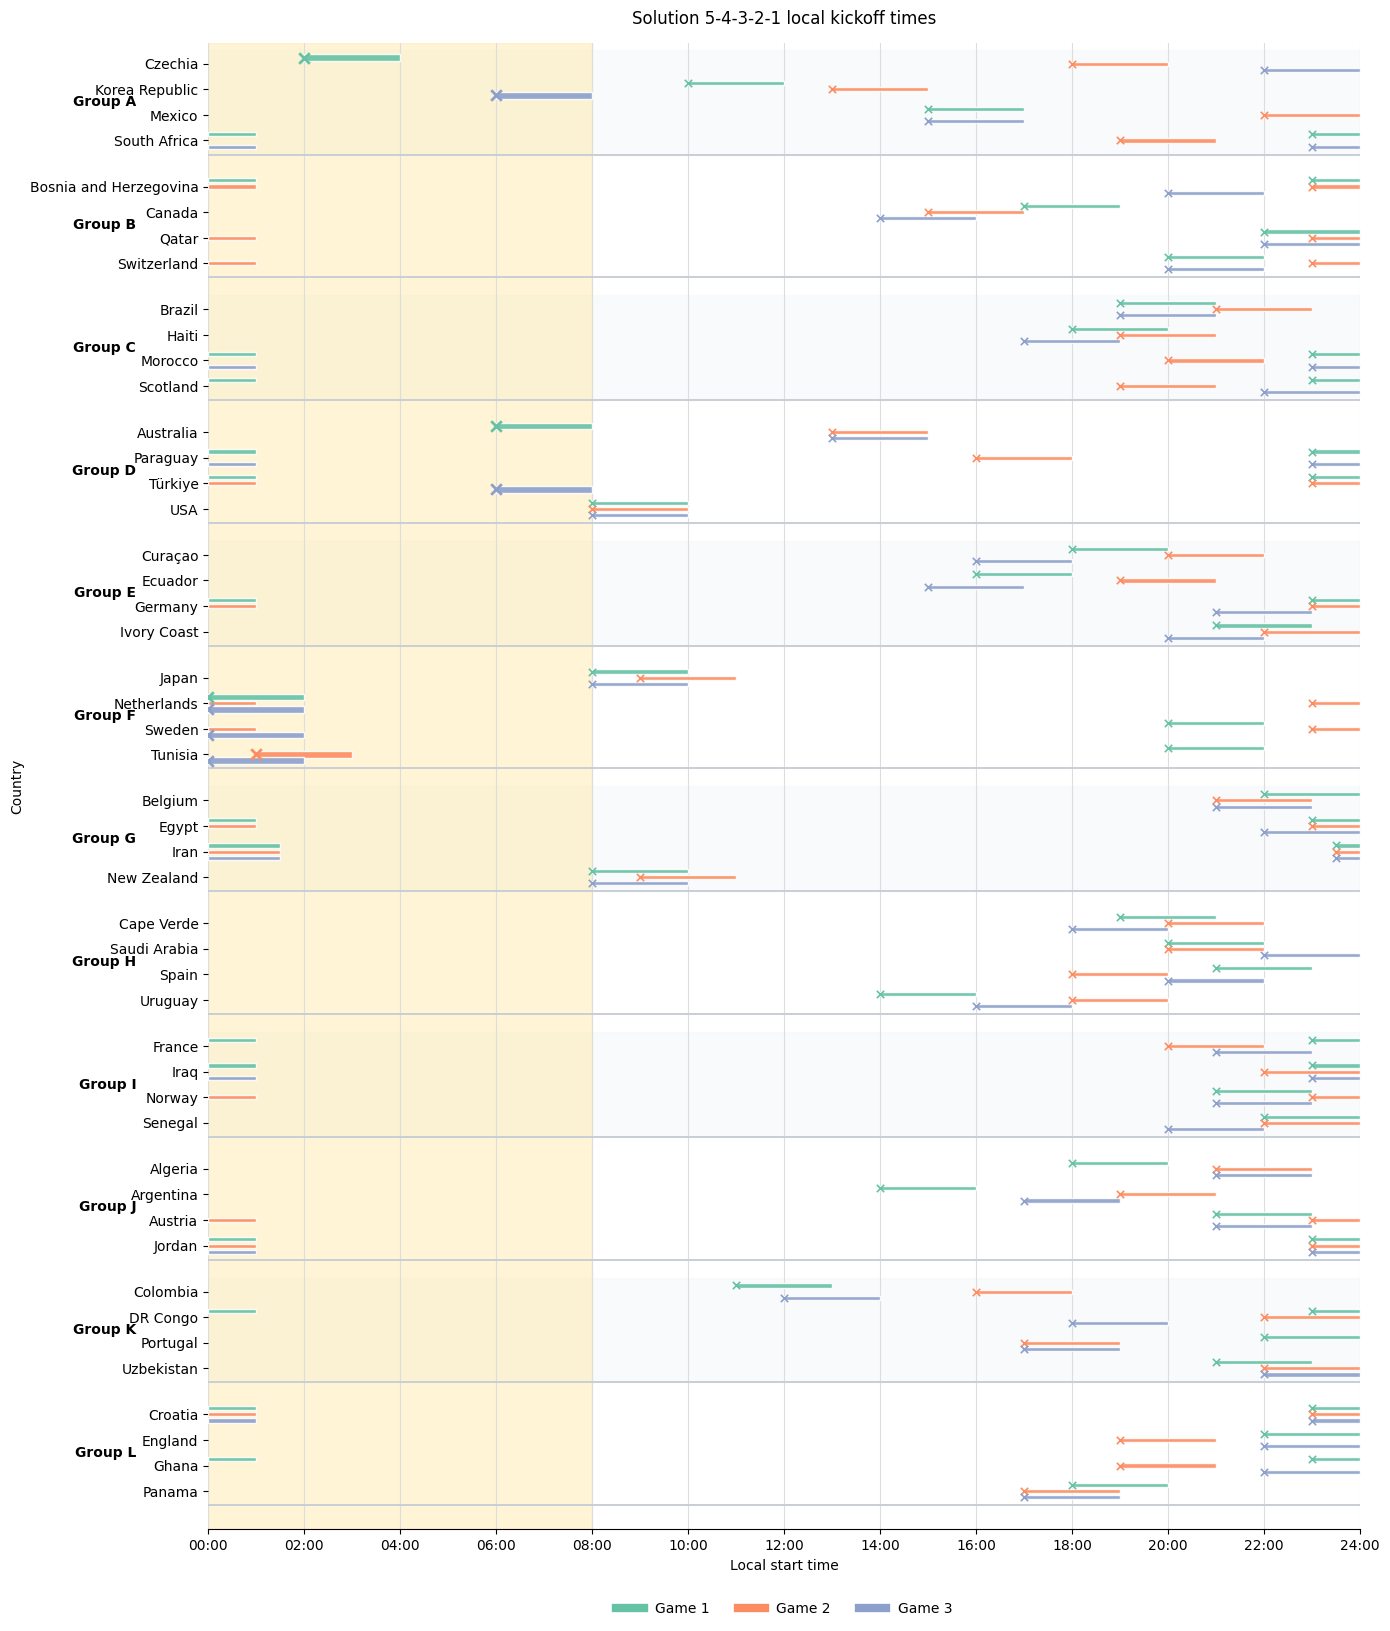

In [15]:
def plot_solution_local_times(solution_df, title="Solution local kickoff times"):
    tz_offsets = df_timezones.set_index("Country")["UTC"]
    games = solution_df.copy()
    games["match_id"] = games.index

    team_games = pd.concat(
        [
            games.rename(columns={"team_1": "country", "team_2": "opponent"}),
            games.rename(columns={"team_2": "country", "team_1": "opponent"}),
        ],
        ignore_index=True,
    )

    missing_timezones = sorted(set(team_games["country"]) - set(tz_offsets.index))
    if missing_timezones:
        raise ValueError(f"Missing timezone offsets for: {missing_timezones}")

    team_games["local_start"] = (team_games["hour_utc"] + team_games["country"].map(tz_offsets)) % 24
    team_games["early_local_start"] = team_games["local_start"].between(0, 8, inclusive="left")
    team_games = team_games.sort_values(["group", "country", "day", "date", "hour_utc"])
    team_games["game_number"] = team_games.groupby("country").cumcount() + 1

    country_order = (
        team_games[["group", "country"]]
        .drop_duplicates()
        .sort_values(["group", "country"])
        .reset_index(drop=True)
    )
    y_base = {}
    current_y = 0
    for _, group_rows in country_order.groupby("group", sort=True):
        for country in group_rows["country"]:
            y_base[country] = current_y
            current_y -= 1
        current_y -= 0.8
    lane_offset = {1: 0.24, 2: 0.0, 3: -0.24}

    palette = sns.color_palette("Set2", n_colors=int(team_games["game_number"].max()))
    game_colors = {game_number: palette[game_number - 1] for game_number in sorted(team_games["game_number"].unique())}

    fig_height = max(10, 0.34 * len(country_order))
    fig, ax = plt.subplots(figsize=(14, fig_height))
    ax.axvspan(0, 8, color="#ffe8a3", alpha=0.45, zorder=0.1, label="00:00-08:00")

    for _, row in team_games.iterrows():
        y = y_base[row["country"]] + lane_offset.get(row["game_number"], 0)
        start = float(row["local_start"])
        color = game_colors[row["game_number"]]
        bar_height = 0.26 if row["early_local_start"] else 0.16
        segments = [(start, min(2, 24 - start))]
        if start + 2 > 24:
            segments.append((0, start + 2 - 24))

        for segment_start, segment_duration in segments:
            ax.broken_barh(
                [(segment_start, segment_duration)],
                (y - bar_height / 2, bar_height),
                facecolors=color,
                edgecolors="white",
                linewidth=1,
                alpha=0.9,
                zorder=2,
            )
        marker_size = 58 if row["early_local_start"] else 28
        marker_linewidth = 2.0 if row["early_local_start"] else 1.2
        ax.scatter(start, y, s=marker_size, color=color, linewidth=marker_linewidth, zorder=3, marker = 'x')
        # ax.text(start + 0.08, y, f"G{row['game_number']}", va="center", fontsize=7, color="#222222")

    ax.set_xlim(0, 24)
    ax.set_xticks(range(0, 25, 2))
    ax.set_xticklabels([f"{hour:02d}:00" for hour in range(0, 25, 2)])
    ax.set_yticks([y_base[country] for country in country_order["country"]])
    ax.set_yticklabels(country_order["country"])
    ax.set_xlabel("Local start time")
    ax.set_ylabel("Country")
    ax.set_title(title, pad=14)
    ax.grid(axis="x", color="#dddddd", linewidth=0.8)
    ax.set_axisbelow(True)

    for i, (group, group_rows) in enumerate(country_order.groupby("group", sort=True)):
        y_values = [y_base[country] for country in group_rows["country"]]
        y_mid = sum(y_values) / len(y_values)
        y_min = min(y_values) - 0.55
        y_max = max(y_values) + 0.55
        if i % 2 == 0:
            ax.axhspan(y_min, y_max, color="#f5f7fa", alpha=0.6, zorder=0)
        ax.text(
            -1.5,
            y_mid,
            f"Group {group}",
            ha="right",
            va="center",
            fontsize=10,
            fontweight="bold",
            clip_on=False,
        )
        ax.axhline(y_min, color="#c9ced6", linewidth=1.4)

    ax.set_ylim(current_y + 0.3, 0.8)

    handles = [plt.Line2D([0], [0], color=game_colors[i], lw=6, label=f"Game {i}") for i in game_colors]
    ax.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, -0.04), ncol=len(handles), frameon=False)
    sns.despine(left=True, bottom=False)
    plt.tight_layout()
    return fig, ax


solution_figures = {}

for solution_key, solution_df in solution_dfs.items():
    fig, ax = plot_solution_local_times(
        solution_df,
        title=f"Solution {solution_key} local kickoff times",
    )
    solution_figures[solution_key] = (fig, ax)
    plt.show()

,group,country,1-2-5-3-4,2-4-3-1-5,4-3-5-2-1,5-1-2-3-4,5-4-3-2-1
0,A,Czechia,2,2,1,1,1
1,A,Korea Republic,0,0,1,1,1
2,A,Mexico,0,0,0,0,0
3,A,South Africa,2,1,2,0,0
4,B,Bosnia and Herzegovina,0,0,1,0,0
5,B,Canada,0,0,0,0,0
6,B,Qatar,2,0,2,0,0
7,B,Switzerland,1,0,2,0,0
8,C,Brazil,0,0,0,0,0
9,C,Haiti,0,0,0,0,0


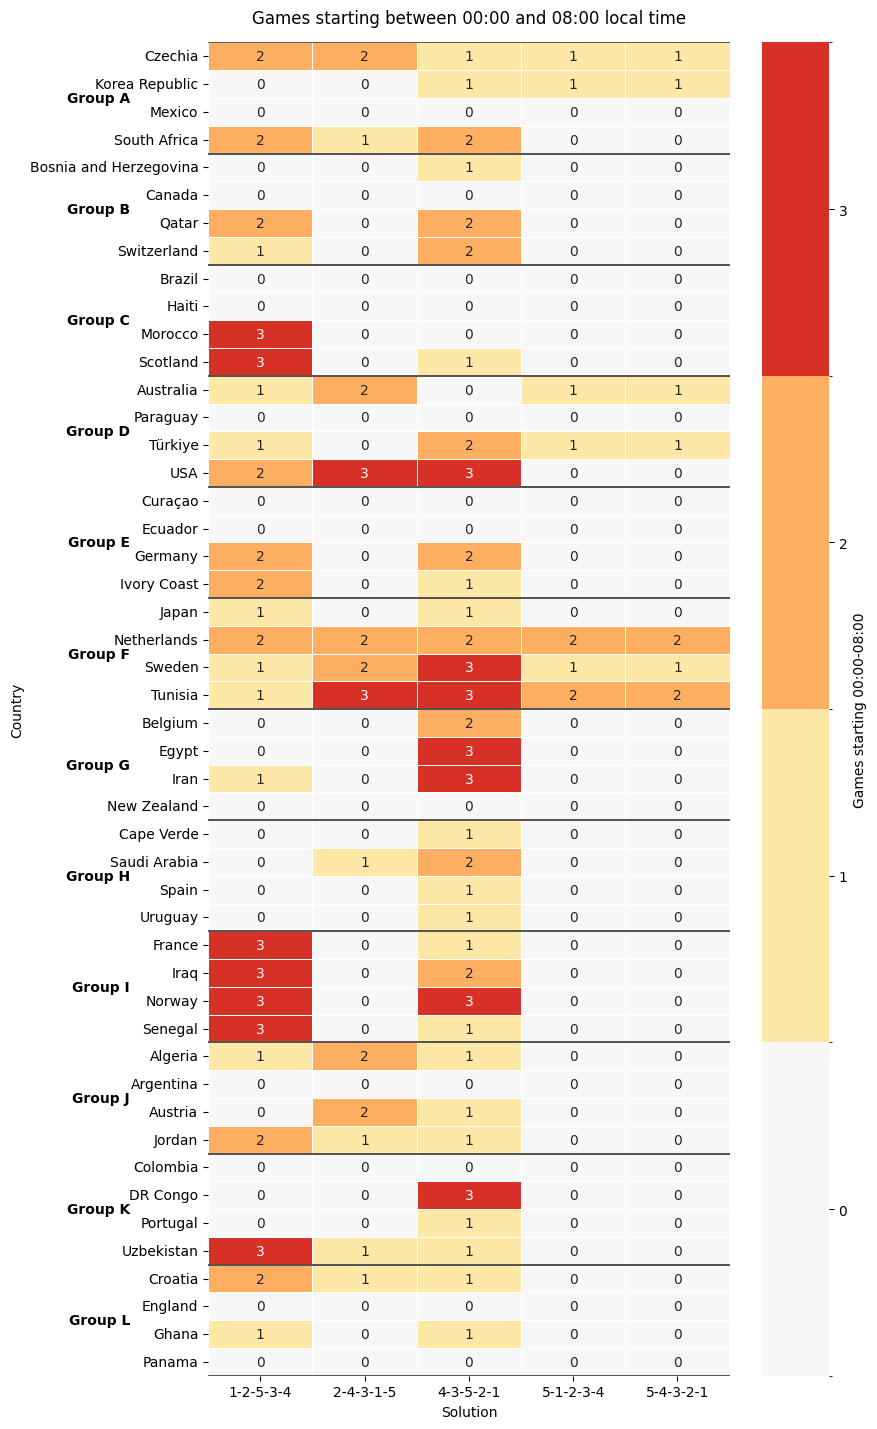

In [18]:
from IPython.display import display
from matplotlib.colors import BoundaryNorm, ListedColormap

def count_early_starts_by_country(solution_df):
    tz_offsets = df_timezones.set_index("Country")["UTC"]
    games = solution_df.copy()

    team_games = pd.concat(
        [
            games.rename(columns={"team_1": "country"}),
            games.rename(columns={"team_2": "country"}),
        ],
        ignore_index=True,
    )
    team_games["local_start"] = (team_games["hour_utc"] + team_games["country"].map(tz_offsets)) % 24
    team_games["early_local_start"] = team_games["local_start"].between(0, 8, inclusive="left")

    country_order = (
        team_games[["group", "country"]]
        .drop_duplicates()
        .sort_values(["group", "country"])
        .reset_index(drop=True)
    )
    counts = (
        team_games.groupby(["group", "country"])["early_local_start"]
        .sum()
        .astype(int)
        .rename("early_games")
    )

    return country_order.join(counts, on=["group", "country"]).fillna({"early_games": 0})


early_start_count_dfs = {
    solution_key: count_early_starts_by_country(solution_df)
    for solution_key, solution_df in solution_dfs.items()
}

early_start_counts_df = pd.concat(
    [
        df.set_index(["group", "country"])["early_games"].rename(solution_key)
        for solution_key, df in early_start_count_dfs.items()
    ],
    axis=1,
).reset_index()

early_start_counts_df = early_start_counts_df.sort_values(["group", "country"])

display(early_start_counts_df)

heatmap_df = early_start_counts_df.set_index("country")[list(solution_dfs)]
group_sizes = early_start_counts_df.groupby("group", sort=False).size()
group_starts = group_sizes.cumsum().shift(fill_value=0)
early_count_cmap = ListedColormap(["#f7f7f7", "#fee8a8", "#fdae61", "#d73027"])
early_count_norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], early_count_cmap.N)

fig, ax = plt.subplots(figsize=(10, max(10, 0.3 * len(heatmap_df))))
sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".0f",
    cmap=early_count_cmap,
    norm=early_count_norm,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Games starting 00:00-08:00", "ticks": [0, 1, 2, 3]},
    ax=ax,
)

for group, start in group_starts.items():
    end = start + group_sizes[group]
    ax.hlines(start, *ax.get_xlim(), color="#555555", linewidth=1.4)
    ax.hlines(end, *ax.get_xlim(), color="#555555", linewidth=1.4)
    ax.text(
        -0.75,
        start + group_sizes[group] / 2,
        f"Group {group}",
        ha="right",
        va="center",
        fontsize=10,
        fontweight="bold",
        clip_on=False,
    )

ax.set_title("Games starting between 00:00 and 08:00 local time", pad=14)
ax.set_xlabel("Solution")
ax.set_ylabel("Country")
plt.tight_layout(rect=(0.12, 0, 1, 1))

,group,country,1-2-5-3-4,2-4-3-1-5,4-3-5-2-1,5-1-2-3-4,5-4-3-2-1
0,A,Czechia,1234.849654,1234.849654,606.448721,628.400933,628.400933
1,A,Korea Republic,0.000000,0.000000,4578.349655,4469.051346,4469.051346
2,A,Mexico,0.000000,0.000000,0.000000,0.000000,0.000000
3,A,South Africa,24568.590804,13436.363524,24568.590804,0.000000,0.000000
4,B,Bosnia and Herzegovina,0.000000,0.000000,506.324136,0.000000,0.000000
5,B,Canada,0.000000,0.000000,0.000000,0.000000,0.000000
6,B,Qatar,1182.416764,0.000000,1310.142454,0.000000,0.000000
7,B,Switzerland,466.338201,0.000000,1059.606885,0.000000,0.000000
8,C,Brazil,0.000000,0.000000,0.000000,0.000000,0.000000
9,C,Haiti,0.000000,0.000000,0.000000,0.000000,0.000000


,solution,total_early_start_cost
3,5-1-2-3-4,15757.942878
4,5-4-3-2-1,15757.942878
0,1-2-5-3-4,200363.306349
1,2-4-3-1-5,203113.345711
2,4-3-5-2-1,277524.131634


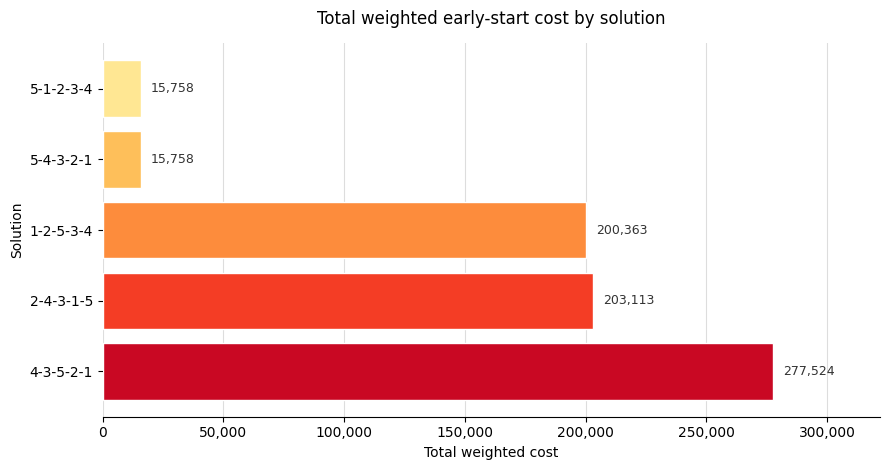

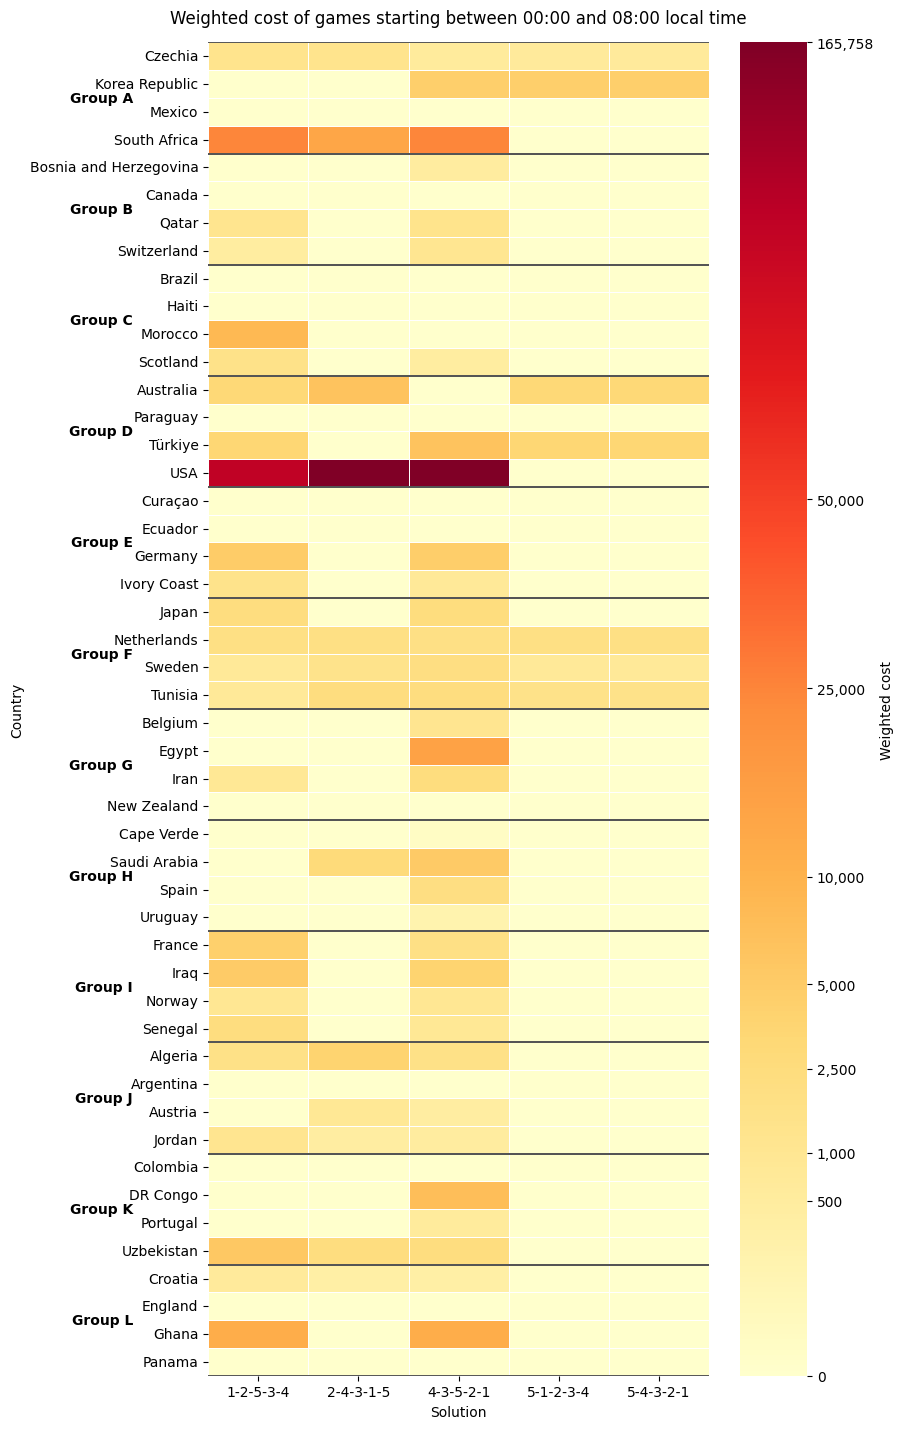

In [26]:
from matplotlib.colors import PowerNorm
from matplotlib.ticker import FuncFormatter

def compute_early_start_cost_by_country(solution_df):
    tz_offsets = df_timezones.set_index("Country")["UTC"]
    weights = df_weights[["country", "opponent", "game_weight_for_country"]].copy()
    games = solution_df.copy()

    team_games = pd.concat(
        [
            games.rename(columns={"team_1": "country", "team_2": "opponent"}),
            games.rename(columns={"team_2": "country", "team_1": "opponent"}),
        ],
        ignore_index=True,
    )
    team_games["local_start"] = (team_games["hour_utc"] + team_games["country"].map(tz_offsets)) % 24
    team_games["early_local_start"] = team_games["local_start"].between(0, 8, inclusive="left")
    team_games = team_games.merge(weights, on=["country", "opponent"], how="left")

    missing_weights = team_games[team_games["game_weight_for_country"].isna()][["country", "opponent"]].drop_duplicates()
    if not missing_weights.empty:
        raise ValueError(f"Missing game weights for:\n{missing_weights.to_string(index=False)}")

    team_games["early_start_cost"] = team_games["game_weight_for_country"] * team_games["early_local_start"]

    country_order = (
        team_games[["group", "country"]]
        .drop_duplicates()
        .sort_values(["group", "country"])
        .reset_index(drop=True)
    )
    costs = (
        team_games.groupby(["group", "country"])["early_start_cost"]
        .sum()
        .rename("early_start_cost")
    )

    return country_order.join(costs, on=["group", "country"]).fillna({"early_start_cost": 0})


early_start_cost_dfs = {
    solution_key: compute_early_start_cost_by_country(solution_df)
    for solution_key, solution_df in solution_dfs.items()
}

early_start_costs_df = pd.concat(
    [
        df.set_index(["group", "country"])["early_start_cost"].rename(solution_key)
        for solution_key, df in early_start_cost_dfs.items()
    ],
    axis=1,
).reset_index()
early_start_costs_df = early_start_costs_df.sort_values(["group", "country"])

solution_total_costs_df = pd.DataFrame(
    {
        "solution": list(solution_dfs),
        "total_early_start_cost": [early_start_costs_df[solution_key].sum() for solution_key in solution_dfs],
    }
).sort_values("total_early_start_cost")

display(early_start_costs_df)
display(solution_total_costs_df)

fig, ax = plt.subplots(figsize=(9, 4.8))
bar_colors = sns.color_palette("YlOrRd", n_colors=len(solution_total_costs_df))
bars = ax.barh(
    solution_total_costs_df["solution"],
    solution_total_costs_df["total_early_start_cost"],
    color=bar_colors,
    edgecolor="white",
    linewidth=1,
)
ax.invert_yaxis()
ax.xaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value:,.0f}"))
ax.set_title("Total weighted early-start cost by solution", pad=14)
ax.set_xlabel("Total weighted cost")
ax.set_ylabel("Solution")
ax.grid(axis="x", color="#dddddd", linewidth=0.8)
ax.set_axisbelow(True)

x_offset = solution_total_costs_df["total_early_start_cost"].max() * 0.015
for bar in bars:
    value = bar.get_width()
    ax.text(
        value + x_offset,
        bar.get_y() + bar.get_height() / 2,
        f"{value:,.0f}",
        va="center",
        fontsize=9,
        color="#333333",
    )

ax.set_xlim(0, solution_total_costs_df["total_early_start_cost"].max() * 1.16)
sns.despine(left=True, bottom=False)
plt.tight_layout()

cost_heatmap_df = early_start_costs_df.set_index("country")[list(solution_dfs)]
cost_vmax = cost_heatmap_df.to_numpy().max()
cost_norm = PowerNorm(gamma=0.35, vmin=0, vmax=cost_vmax)
cost_ticks = [0, 500, 1000, 2500, 5000, 10000, 25000, 50000]
cost_ticks = [tick for tick in cost_ticks if tick <= cost_vmax]
if cost_ticks[-1] != cost_vmax:
    cost_ticks.append(cost_vmax)

fig, ax = plt.subplots(figsize=(10, max(10, 0.3 * len(cost_heatmap_df))))
sns.heatmap(
    cost_heatmap_df,
    cmap="YlOrRd",
    norm=cost_norm,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Weighted cost", "ticks": cost_ticks},
    ax=ax,
)
ax.collections[0].colorbar.ax.yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value:,.0f}"))

for group, start in group_starts.items():
    end = start + group_sizes[group]
    ax.hlines(start, *ax.get_xlim(), color="#555555", linewidth=1.4)
    ax.hlines(end, *ax.get_xlim(), color="#555555", linewidth=1.4)
    ax.text(
        -0.75,
        start + group_sizes[group] / 2,
        f"Group {group}",
        ha="right",
        va="center",
        fontsize=10,
        fontweight="bold",
        clip_on=False,
    )

ax.set_title("Weighted cost of games starting between 00:00 and 08:00 local time", pad=14)
ax.set_xlabel("Solution")
ax.set_ylabel("Country")
plt.tight_layout(rect=(0.12, 0, 1, 1))